<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya_new/blob/classification-models/XGb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:37:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBClassifier
Accuracy: 0.8607142857142858
Balanced Accuracy: 0.761204481792717
ROC AUC: 0.7947178871548619
F1 Score: 0.5714285714285714
Cohen's Kappa: 0.4888597640891219
Mean Absolute Error: 0.1392857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       238
           1       0.53      0.62      0.57        42

    accuracy                           0.86       280
   macro avg       0.73      0.76      0.74       280
weighted avg       0.87      0.86      0.87       280



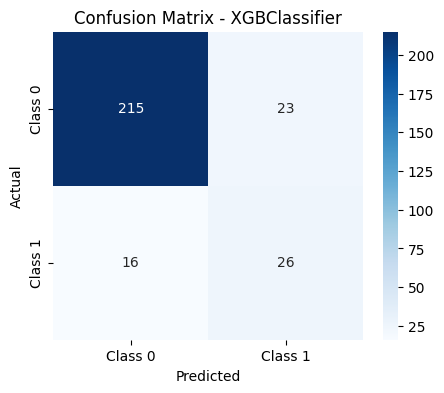

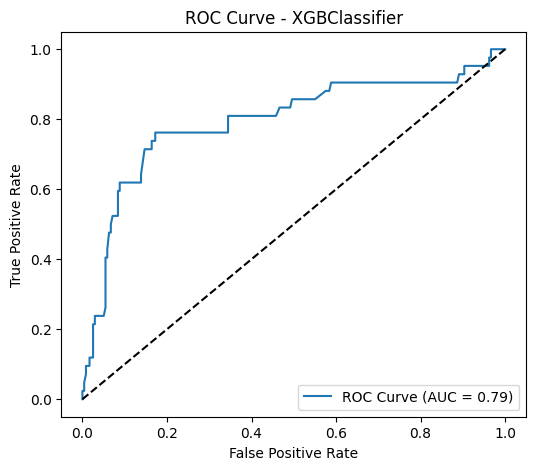

In [3]:
!pip install xgboost matplotlib seaborn scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score, mean_absolute_error,
    roc_curve
)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("/content/MACCS2_Trainset_top20.csv")  # change path if needed

# Features and target
X = df.drop(columns=["BioactivityClass"])
y = df["BioactivityClass"]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
print("Model: XGBClassifier")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBClassifier')
plt.show()

# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBClassifier')
plt.legend(loc='lower right')
plt.show()
